# Mathematik II/B — Übung [Nr] (WT 2026)

**Thema:** [Thema eintragen]
**Datum:** [Datum eintragen]
**Dozent/in:** [Name eintragen]

---

## 📖 Inhaltsverzeichnis

0. [🔄 Wiederholung – Aus Übung [Nr-1]](#wiederholung)
1. [📖 Theoretischer Hintergrund](#theorie)
2. [📝 Aufgabeblatt [Nr] – Mathematik II/B Übung [Nr]](#aufgabeblatt)
   - [Aufgabe [Nr].1](#aufgabe1)
   - [Aufgabe [Nr].2](#aufgabe2)
   - [Aufgabe [Nr].3](#aufgabe3)
3. [💡 Lösungstipps](#tipps)

---

In [4]:
# Imports
# load the packages you need
import numpy as np
import matplotlib.pyplot as plt
import math
import sympy as sp
import pandas as pd
from IPython.display import display, Math, HTML, Markdown

from ipywidgets import interact, FloatSlider, IntSlider, Dropdown, interactive
import ipywidgets as widgets

# Konfiguration für schönere Plots
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 11

print("✓ Alle Pakete erfolgreich geladen!")

✓ Alle Pakete erfolgreich geladen!


<a id="wiederholung"></a>
## 🔄 Wiederholung – Aus Übung [Nr-1]

Zur Auffrischung: In Übung [Nr-1] haben Sie gelernt, wie man ...
Hier sind **Selbstkontrolle-Aufgaben** aus Übung [Nr-1] – versuchen Sie diese selbstständig zu lösen, bevor Sie die Lösung anschauen.

---

In [76]:
from IPython.display import display, HTML, Markdown
from ipywidgets import VBox, Button, Output

def create_solution_toggle(problem_markdown, solution_markdown, solution_title="Lösung anzeigen", plot_callback=None):
    """
    Erstellt ein interaktives Toggle-Element für Lösungen mit ipywidgets
    
    Args:
        problem_markdown: Aufgabentext (Markdown format for proper LaTeX rendering)
        solution_markdown: Lösungstext (Markdown format for proper LaTeX rendering)
        solution_title: Titel des Lösungsblocks
        plot_callback: Optional function to call when solution is shown (for generating plots)
    """
    # Problem-Container using Output widget
    problem_output = Output()
    with problem_output:
        display(Markdown(f"""
<div style="background-color: #f9f9f9; border-left: 4px solid #0066cc; padding: 20px; margin: 20px 0; border-radius: 5px;">
<h3 style="color: #333;">📝 Aufgabe zur Wiederholung</h3>

{problem_markdown}

</div>
        """))
    
    # Button
    button = Button(description=f"▶ {solution_title}", 
                   button_style='info',
                   tooltip='Klicken zum Anzeigen der Lösung',
                   layout={'width': '200px', 'padding': '10px', 'font_size': '13px'})
    
    # Output für Lösung
    output = Output()
    
    is_shown = [False]  # Mutable flag to track visibility
    
    def toggle_solution(b):
        output.clear_output()
        is_shown[0] = not is_shown[0]
        
        if is_shown[0]:
            button.description = f"▼ Lösung verbergen"
            with output:
                # Use Markdown for proper LaTeX rendering
                display(Markdown(f"""
<div style="margin-top: 15px; background-color: #e8f4f8; padding: 15px; border-radius: 5px; border: 1px solid #00ccff;">

{solution_markdown}

</div>
                """))
                # Call plot callback if provided
                if plot_callback is not None:
                    plot_callback()
        else:
            button.description = f"▶ {solution_title}"
    
    button.on_click(toggle_solution)
    
    return VBox([problem_output, button, output])

#print("✓ Wiederholungs-Widget geladen!")

In [5]:
def plot_function_analysis(
    x_range,
    x_values=None,
    y_values=None,
    func=None,
    maxima=None,
    minima=None,
    nullstellen=None,
    sattelpunkte=None,
    wendepunkte=None,
    asymptoten=None,
    title='Function Analysis',
    x_label='x',
    y_label='f(x)',
    y_limits=None,
    show_inline_labels=True,
    show_grid=True,
    show_legend=True
):
    """
    Visualisiert eine Funktionsanalyse mit automatischer Erkennung und Markierung kritischer Punkte.
    
    Args:
        x_range: (xmin, xmax) Bereich für die x-Achse
        x_values: Optional. Die x-Werte zum Plotten (wenn nicht gegeben, aus func generiert)
        y_values: Optional. Die y-Werte zum Plotten (wenn nicht gegeben, aus func generiert)
        func: Optional. Die Funktion f(x) (wird ignoriert, wenn x_values und y_values gegeben)
        maxima: Liste von (x, y) Maxima
        minima: Liste von (x, y) Minima
        nullstellen: Liste von (x, y) Nullstellen
        sattelpunkte: Liste von (x, y) Sattelpunkte
        wendepunkte: Liste von (x, y) Wendepunkte
        asymptoten: Dict mit Schlüsseln 'vertical', 'horizontal', 'oblique', 'curved'
        title: Titel des Plots
        x_label: Label für x-Achse
        y_label: Label für y-Achse
        y_limits: (ymin, ymax) oder None
        show_inline_labels: Inline-Labels für Punkte anzeigen
        show_grid: Gitter anzeigen
        show_legend: Legende anzeigen
    """
    
    # Generiere x_values und y_values wenn nicht gegeben
    if x_values is None and y_values is None:
        if func is None:
            raise ValueError("Entweder 'func' oder 'x_values' und 'y_values' müssen gegeben sein")
        xmin, xmax = x_range
        x_values = np.linspace(xmin, xmax, 400)
        y_values = func(x_values)
    
    # Default values
    xmin, xmax = x_range
    maxima = maxima or []
    minima = minima or []
    nullstellen = nullstellen or []
    sattelpunkte = sattelpunkte or []
    wendepunkte = wendepunkte or []
    asymptoten = asymptoten or {}
    
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.plot(x_values, y_values, linewidth=2.5, label='f(x)')
    ax.axhline(0, color='black', linewidth=1.5)
    ax.axvline(0, color='black', linewidth=1.5)

    # Collect all special points for overlap detection
    all_points = []
    if maxima:
        for p in maxima:
            all_points.append((p[0], p[1], 'Max', 'crimson', '^'))
    if minima:
        for p in minima:
            all_points.append((p[0], p[1], 'Min', 'navy', 'v'))
    if nullstellen:
        for p in nullstellen:
            all_points.append((p[0], p[1], 'NS', 'black', 'o'))
    if sattelpunkte:
        for p in sattelpunkte:
            all_points.append((p[0], p[1], 'SP', 'orange', 's'))
    if wendepunkte:
        for p in wendepunkte:
            all_points.append((p[0], p[1], 'WP', 'purple', 'D'))

    # Merge overlapping points (within tolerance)
    tolerance = 0.01 * (xmax - xmin)  # 1% of x-range
    merged_points = []
    used = set()
    
    for i, (x1, y1, label1, color1, marker1) in enumerate(all_points):
        if i in used:
            continue
        labels = [label1]
        colors = [color1]
        marker = 'D'  # Rectangle for merged points
        
        for j, (x2, y2, label2, color2, marker2) in enumerate(all_points):
            if i != j and j not in used:
                if abs(x1 - x2) < tolerance and abs(y1 - y2) < tolerance:
                    labels.append(label2)
                    colors.append(color2)
                    used.add(j)
        
        used.add(i)
        merged_label = '/'.join(labels)
        merged_color = colors[0]  # Use first color
        merged_points.append((x1, y1, merged_label, merged_color, marker))
    
    # Plot merged points
    for px, py, label, color, marker in merged_points:
        ax.scatter([px], [py], s=80, c=color, marker=marker, zorder=5)
        if show_inline_labels:
            ax.text(px, py, f" {label}", fontsize=9, 
                   verticalalignment='bottom', bbox=dict(boxstyle='round', 
                   facecolor='white', alpha=0.8))

    # Asymptotes (dashed lines) with inline labels
    if asymptoten:
        for x0 in asymptoten.get('vertical', []):
            ax.axvline(x0, color='gray', linestyle='--', linewidth=1.5, label=f'x = {x0}')
            if show_inline_labels:
                y_pos = ax.get_ylim()[1] * 0.9 if y_limits is None else y_limits[1] * 0.9
                ax.text(x0, y_pos, f'x={x0}', fontsize=9, color='gray',
                       bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
        
        for y0 in asymptoten.get('horizontal', []):
            ax.axhline(y0, color='gray', linestyle='--', linewidth=1.5, label=f'y = {y0}')
            if show_inline_labels:
                x_pos = xmax * 0.85
                ax.text(x_pos, y0, f'y={y0}', fontsize=9, color='gray',
                       bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
        
        for line in asymptoten.get('oblique', []):
            if isinstance(line, (list, tuple)) and len(line) == 2:
                m, b = line
                ax.plot(x_values, m * x_values + b, color='gray', linestyle='--', linewidth=1.5, label=f'y = {m}x + {b}')
                if show_inline_labels:
                    x_pos = xmax * 0.85
                    y_pos = m * x_pos + b
                    equation = f'y = {m}x + {b}' if b >= 0 else f'y = {m}x - {abs(b)}'
                    ax.text(x_pos, y_pos, equation, fontsize=9, color='gray',
                           bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
        
        for curve in asymptoten.get('curved', []):
            if isinstance(curve, tuple) and len(curve) == 2 and callable(curve[0]):
                # (function, label) format
                func_curve, label_curve = curve
                try:
                    y_curve = func_curve(x_values)
                    ax.plot(x_values, y_curve, color='gray', linestyle='--', linewidth=1.5, label=label_curve)
                    if show_inline_labels:
                        # Place label safely inside the plot area at center
                        x_pos = (xmin + xmax) / 2  # Middle of x-range
                        try:
                            y_pos_val = func_curve(np.array([x_pos]))[0]
                        except:
                            y_pos_val = 0
                        
                        # Clamp to middle 80% of y-range for safety
                        if y_limits is not None:
                            y_min, y_max = y_limits
                            y_center = (y_min + y_max) / 2
                            y_range = (y_max - y_min) * 0.4
                            y_pos_val = np.clip(y_pos_val, y_center - y_range, y_center + y_range)
                        
                        ax.text(x_pos, y_pos_val, label_curve, fontsize=9, color='gray',
                               bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
                except Exception as e:
                    print(f"Fehler beim Plotten der kurvenförmigen Asymptote: {e}")
            elif callable(curve):
                # Just a function
                try:
                    y_curve = curve(x_values)
                    ax.plot(x_values, y_curve, color='gray', linestyle='--', linewidth=1.5, label='Kurvenförmige Asymptote')
                except Exception as e:
                    print(f"Fehler beim Plotten der kurvenförmigen Asymptote: {e}")

    if show_grid:
        ax.grid(True, alpha=0.3)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel(x_label, fontsize=11, fontweight='bold')
    ax.set_ylabel(y_label, fontsize=11, fontweight='bold')
    if y_limits is not None:
        ax.set_ylim(*y_limits)
    if show_legend:
        ax.legend(fontsize=10)
    plt.subplots_adjust(bottom=0.15, left=0.12, right=0.95, top=0.93)
    plt.show()

def plot_convergence(
    n_values,
    a_n,
    limit,
    n_max,
    distance=None,
    epsilon=0.01,
    yscale='log',
    title='Konvergenz einer Folge'
):
    """
    Visualisiert die Konvergenz einer Folge bis zu einem bestimmten n_max.
    
    Args:
        n_values: Array der Indizes n
        a_n: Array der Folgenglieder
        limit: Der Grenzwert L
        n_max: Maximaler n-Wert der angezeigt werden soll
        distance: Optional. Array der Abstände |a_n - L| (wird berechnet wenn nicht gegeben)
        epsilon: Toleranz-Schwellenwert
        yscale: 'linear' oder 'log'
        title: Titel des Plots
    """
    if distance is None:
        distance = np.abs(a_n - limit)
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    
    # Plot 1: Folgenglieder und Grenzwert
    mask = n_values <= n_max
    ax1.plot(n_values[mask], a_n[mask], 'b.-', markersize=6, label=f'$a_n$')
    ax1.axhline(limit, color='red', linestyle='--', linewidth=2, label=f'Grenzwert L = {limit}')
    ax1.fill_between(n_values[mask], limit - epsilon, limit + epsilon, alpha=0.2, color='green', label=f'±ε = ±{epsilon}')
    ax1.set_xlabel('n', fontsize=11)
    ax1.set_ylabel('$a_n$', fontsize=11)
    ax1.set_title(title, fontsize=12, fontweight='bold')
    ax1.legend(fontsize=10)
    ax1.grid(True, alpha=0.3)
    ax1.set_xlim(1, max(n_values) * 1.05)
    
    # Plot 2: Abstand zum Grenzwert (logarithmisch)
    ax2.semilogy(n_values[mask], distance[mask], 'g.-', markersize=6, label='$|a_n - L|$')
    ax2.axhline(epsilon, color='red', linestyle='--', linewidth=2, label=f'ε = {epsilon}')
    ax2.set_xlabel('n', fontsize=11)
    ax2.set_ylabel('$|a_n - L|$', fontsize=11)
    ax2.set_title('Konvergenzgeschwindigkeit (logarithmisch)', fontsize=12, fontweight='bold')
    ax2.legend(fontsize=10)
    ax2.grid(True, alpha=0.3, which='both')
    ax2.set_xlim(1, max(n_values) * 1.05)
    
    plt.tight_layout()
    plt.show()
    
    # Ausgabe von Konvergenzstatistik
    epsilon_reached = np.where(distance <= epsilon)[0]
    if len(epsilon_reached) > 0:
        n_critical = n_values[epsilon_reached[0]]
        print(f"✓ Ab n ≥ {n_critical} ist |a_n - L| < ε = {epsilon}")


In [78]:
# --- Demo: Interaktive Konvergenz mit Slider ---

# Definiere die Folge
n_vals = np.arange(1, 201, 1)
a_vals = n_vals / (n_vals + 1)
distance_vals = np.abs(a_vals - 1)

print("Demo: Interaktive Konvergenz mit Schieberegler")
print("Verwenden Sie den Schieberegler, um verschiedene n_max-Werte zu erkunden!")
print("-" * 60)

# Verwende interact direkt mit plot_convergence
from ipywidgets import IntSlider, interact

slider = IntSlider(
    value=50,
    min=10,
    max=200,
    step=10,
    description='n_max:',
    style={'description_width': '80px'},
    layout={'width': '500px'}
)

interact(
    lambda n_max: plot_convergence(
        n_values=n_vals,
        a_n=a_vals,
        limit=1,
        n_max=n_max,
        distance=distance_vals,
        epsilon=0.01,
        title='Konvergenz der Folge $a_n = \\frac{n}{n+1}$ gegen Grenzwert 1'
    ),
    n_max=slider
)

Demo: Interaktive Konvergenz mit Schieberegler
Verwenden Sie den Schieberegler, um verschiedene n_max-Werte zu erkunden!
------------------------------------------------------------


interactive(children=(IntSlider(value=50, description='n_max:', layout=Layout(width='500px'), max=200, min=10,…

<function __main__.<lambda>(n_max)>

In [6]:
def plot_parametric_curve_2d(
    r_func,
    t_range,
    eval_points=None,
    show_tangent=True,
    show_normal=True,
    show_second_derivative=True,
    vector_scale=1.0,
    num_points=400,
    title='Parametrische Kurve',
    x_label='x',
    y_label='y',
    curve_color='blue',
    tangent_color='green',
    normal_color='red',
    second_deriv_color='red',
    figsize=(10, 8)
):
    """
    Visualisiert eine parametrische 2D-Kurve mit Tangenten-, Normalen- und zweiten Ableitungsvektoren.
    
    Args:
        r_func: Funktion r(t) die einen Tupel/Array (x(t), y(t)) zurückgibt
        t_range: (t_min, t_max) Bereich für den Parameter t
        eval_points: Liste von t-Werten, an denen Tangenten/Normalen gezeigt werden sollen
        show_tangent: Tangentenvektoren anzeigen
        show_normal: Normalenvektoren anzeigen
        show_second_derivative: Zweite Ableitungsvektoren anzeigen (als gestrichelte rote Linie)
        vector_scale: Skalierungsfaktor für die Vektoren
        num_points: Anzahl der Punkte für die Kurve
        title: Titel des Plots
        x_label: Label für x-Achse
        y_label: Label für y-Achse
        curve_color: Farbe der Kurve
        tangent_color: Farbe der Tangentenvektoren
        normal_color: Farbe der Normalenvektoren
        second_deriv_color: Farbe der zweiten Ableitungsvektoren
        figsize: Größe der Figur
    
    Beispiel:
        def r(t):
            return (np.abs(t), t**3)
        
        plot_parametric_curve_2d(r, (-3, 3), eval_points=[2], vector_scale=0.5)
    """
    
    # Erzeuge t-Werte für die Kurve
    t_min, t_max = t_range
    t_values = np.linspace(t_min, t_max, num_points)
    
    # Berechne Kurvenpunkte
    curve_points = np.array([r_func(t) for t in t_values])
    x_curve = curve_points[:, 0]
    y_curve = curve_points[:, 1]
    
    # Erstelle Plot
    fig, ax = plt.subplots(figsize=figsize)
    
    # Plotte die Kurve
    ax.plot(x_curve, y_curve, color=curve_color, linewidth=2.5, label='$r(t)$', zorder=1)
    
    # Wenn Evaluationspunkte gegeben sind
    if eval_points:
        for t_eval in eval_points:
            # Berechne Position auf der Kurve
            r_t = np.array(r_func(t_eval))
            x_t, y_t = r_t
            
            # Markiere den Punkt auf der Kurve
            ax.scatter([x_t], [y_t], s=100, c='black', marker='o', zorder=5, 
                      label=f'$r({t_eval})$' if t_eval == eval_points[0] else '')
            
            # Berechne numerische Ableitung (Tangentenvektor)
            h = 0.001
            r_t_plus = np.array(r_func(t_eval + h))
            r_t_minus = np.array(r_func(t_eval - h))
            dr_dt = (r_t_plus - r_t_minus) / (2 * h)
            
            # Normalisiere und skaliere den Tangentenvektor
            tangent_length = np.linalg.norm(dr_dt)
            if tangent_length > 0:
                dr_dt_normalized = dr_dt / tangent_length * vector_scale
            else:
                dr_dt_normalized = dr_dt
            
            # Berechne Normalenvektor (90° Drehung im Uhrzeigersinn: (x,y) -> (y,-x))
            # oder gegen Uhrzeigersinn: (x,y) -> (-y,x)
            normal_vec = np.array([-dr_dt_normalized[1], dr_dt_normalized[0]])
            
            # Berechne numerische zweite Ableitung
            h = 0.001
            r_t = np.array(r_func(t_eval))
            r_t_plus_2h = np.array(r_func(t_eval + 2*h))
            r_t_plus = np.array(r_func(t_eval + h))
            r_t_minus = np.array(r_func(t_eval - h))
            r_t_minus_2h = np.array(r_func(t_eval - 2*h))
            
            # Zweite Ableitung: r''(t) ≈ (r(t+2h) - 2*r(t) + r(t-2h)) / (4h²)
            d2r_dt2 = (r_t_plus_2h - 2*r_t + r_t_minus_2h) / (4 * h**2)
            
            # Normalisiere und skaliere den zweiten Ableitungsvektor
            second_deriv_length = np.linalg.norm(d2r_dt2)
            if second_deriv_length > 0:
                d2r_dt2_normalized = d2r_dt2 / second_deriv_length * vector_scale
            else:
                d2r_dt2_normalized = d2r_dt2
            
            # Plotte Tangentenvektor
            if show_tangent:
                ax.arrow(x_t, y_t, dr_dt_normalized[0], dr_dt_normalized[1],
                        head_width=0.15, head_length=0.1, fc=tangent_color, 
                        ec=tangent_color, linewidth=2, zorder=4,
                        label='Tangentenvektor' if t_eval == eval_points[0] else '')
                # Beschriftung für Tangentenvektor
                ax.text(x_t + dr_dt_normalized[0] * 1.2, y_t + dr_dt_normalized[1] * 1.2,
                       f"$r'({t_eval})$", fontsize=10, color=tangent_color,
                       bbox=dict(boxstyle='round', facecolor='white', alpha=0.7))
            
            # Plotte Normalenvektor
            if show_normal:
                ax.arrow(x_t, y_t, normal_vec[0], normal_vec[1],
                        head_width=0.15, head_length=0.1, fc=normal_color, 
                        ec=normal_color, linewidth=2, zorder=4,
                        label='Normalenvektor' if t_eval == eval_points[0] else '')
                # Beschriftung für Normalenvektor
                ax.text(x_t + normal_vec[0] * 1.2, y_t + normal_vec[1] * 1.2,
                       f"$n({t_eval})$", fontsize=10, color=normal_color,
                       bbox=dict(boxstyle='round', facecolor='white', alpha=0.7))
            
            # Plotte zweiten Ableitungsvektor (als gestrichelte Linie)
            if show_second_derivative:
                ax.arrow(x_t, y_t, d2r_dt2_normalized[0], d2r_dt2_normalized[1],
                        head_width=0.15, head_length=0.1, fc=second_deriv_color, 
                        ec=second_deriv_color, linewidth=2, linestyle='--', zorder=4,
                        label='Zweite Ableitung' if t_eval == eval_points[0] else '')
                # Beschriftung für zweiten Ableitungsvektor
                ax.text(x_t + d2r_dt2_normalized[0] * 1.2, y_t + d2r_dt2_normalized[1] * 1.2,
                       f"$r''({t_eval})$", fontsize=10, color=second_deriv_color,
                       bbox=dict(boxstyle='round', facecolor='white', alpha=0.7))
            
            # Zeige t-Wert am Punkt
            ax.text(x_t, y_t - 0.3, f't={t_eval}', fontsize=9, ha='center',
                   bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.6))
    
    # Formatierung
    ax.axhline(0, color='black', linewidth=0.8, alpha=0.3)
    ax.axvline(0, color='black', linewidth=0.8, alpha=0.3)
    ax.grid(True, alpha=0.3)
    ax.set_xlabel(x_label, fontsize=11, fontweight='bold')
    ax.set_ylabel(y_label, fontsize=11, fontweight='bold')
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_aspect('equal', adjustable='box')
    ax.legend(fontsize=10, loc='best')
    
    plt.tight_layout()
    plt.show()
    
    # Ausgabe von Informationen
    if eval_points:
        print("=" * 60)
        print("Informationen zu den Evaluationspunkten:")
        print("=" * 60)
        for t_eval in eval_points:
            r_t = np.array(r_func(t_eval))
            h = 0.001
            r_t_plus = np.array(r_func(t_eval + h))
            r_t_minus = np.array(r_func(t_eval - h))
            dr_dt = (r_t_plus - r_t_minus) / (2 * h)
            
            # Zweite Ableitung
            r_t_plus_2h = np.array(r_func(t_eval + 2*h))
            r_t_minus_2h = np.array(r_func(t_eval - 2*h))
            d2r_dt2 = (r_t_plus_2h - 2*r_t + r_t_minus_2h) / (4 * h**2)
            
            normal_vec = np.array([-dr_dt[1], dr_dt[0]])
            
            print(f"\nBei t = {t_eval}:")
            print(f"  Position r({t_eval}) = ({r_t[0]:.4f}, {r_t[1]:.4f})")
            print(f"  Tangentenvektor r'({t_eval}) ≈ ({dr_dt[0]:.4f}, {dr_dt[1]:.4f})")
            print(f"  Normalenvektor n({t_eval}) ≈ ({normal_vec[0]:.4f}, {normal_vec[1]:.4f})")
            print(f"  Zweite Ableitung r''({t_eval}) ≈ ({d2r_dt2[0]:.4f}, {d2r_dt2[1]:.4f})")
            print(f"  |r'({t_eval})| ≈ {np.linalg.norm(dr_dt):.4f}")
            print(f"  |r''({t_eval})| ≈ {np.linalg.norm(d2r_dt2):.4f}")
        print("=" * 60)

def make_interactive_slider(plot_func, param_name, param_values, **fixed_kwargs):
    """
    Macht eine Plot-Funktion interaktiv mit einem Schieberegler.
    
    Args:
        plot_func: Die Plot-Funktion, die aufgerufen werden soll
        param_name: Name des Parameters, der variiert werden soll (z.B. 'eval_points')
        param_values: Liste der möglichen Werte für den Parameter
        **fixed_kwargs: Alle anderen festen Parameter für die Plot-Funktion
    
    Beispiel:
        # Macht plot_parametric_curve_2d interaktiv für verschiedene t-Werte
        make_interactive_slider(
            plot_parametric_curve_2d,
            param_name='eval_points',
            param_values=[0, 1, 2, 3, 4],
            r_func=my_curve,
            t_range=(-5, 5),
            vector_scale=0.5
        )
    """
    from ipywidgets import FloatSlider, interact
    
    def wrapper(param_val):
        """Wrapper-Funktion die den variablen Parameter setzt"""
        # Setze den variablen Parameter
        kwargs = fixed_kwargs.copy()
        kwargs[param_name] = [param_val]  # Als Liste für eval_points
        
        # Rufe die Original-Plot-Funktion auf
        plot_func(**kwargs)
    
    # Bestimme min/max und step für den Slider
    param_min = min(param_values)
    param_max = max(param_values)
    
    if len(param_values) > 1:
        # Finde die kleinste Differenz zwischen aufeinanderfolgenden Werten
        diffs = [abs(param_values[i+1] - param_values[i]) for i in range(len(param_values)-1)]
        step = min(diffs)
    else:
        step = 0.1
    
    # Erstelle Slider
    slider = FloatSlider(
        value=param_values[0] if len(param_values) > 0 else 0,
        min=param_min,
        max=param_max,
        step=step,
        description=f'{param_name}:',
        style={'description_width': '100px'},
        layout={'width': '500px'}
    )
    
    # Erstelle interaktiven Plot
    interact(wrapper, param_val=slider)

In [7]:

# --- 3D Parametrische Kurven ---
from mpl_toolkits.mplot3d import Axes3D

def plot_parametric_curve_3d(
    r_func,
    t_range,
    eval_points=None,
    show_tangent=True,
    show_normal=False,
    show_second_derivative=False,
    vector_scale=1.0,
    num_points=400,
    title='3D Parametrische Kurve',
    x_label='x',
    y_label='y',
    z_label='z',
    curve_color='blue',
    tangent_color='green',
    normal_color='red',
    second_deriv_color='orange',
    figsize=(12, 9),
    elev=20,
    azim=45
):
    """
    Visualisiert eine parametrische 3D-Kurve mit optionalen Vektoren.
    
    Args:
        r_func: Funktion r(t) die einen Tupel/Array (x(t), y(t), z(t)) zurückgibt
        t_range: (t_min, t_max) Bereich für den Parameter t
        eval_points: Liste von t-Werten, an denen Vektoren gezeigt werden sollen
        show_tangent: Tangentenvektoren anzeigen
        show_normal: Normalenvektoren anzeigen
        show_second_derivative: Zweite Ableitungsvektoren anzeigen
        vector_scale: Skalierungsfaktor für die Vektoren
        num_points: Anzahl der Punkte für die Kurve
        title: Titel des Plots
        x_label, y_label, z_label: Achsenlabels
        curve_color: Farbe der Kurve
        tangent_color: Farbe der Tangentenvektoren
        normal_color: Farbe der Normalenvektoren
        second_deriv_color: Farbe der zweiten Ableitungsvektoren
        figsize: Größe der Figur
        elev: Elevation angle in degrees (Blickwinkel)
        azim: Azimuth angle in degrees (Blickwinkel)
    
    Beispiel:
        def r(t):
            return (np.cos(t), np.sin(t), t/5)  # Helix
        
        plot_parametric_curve_3d(r, (0, 4*np.pi), eval_points=[0, np.pi])
    """
    
    # Erzeuge t-Werte für die Kurve
    t_min, t_max = t_range
    t_values = np.linspace(t_min, t_max, num_points)
    
    # Berechne Kurvenpunkte
    curve_points = np.array([r_func(t) for t in t_values])
    x_curve = curve_points[:, 0]
    y_curve = curve_points[:, 1]
    z_curve = curve_points[:, 2]
    
    # Erstelle 3D Plot
    fig = plt.figure(figsize=figsize)
    ax = fig.add_subplot(111, projection='3d')
    
    # Plotte die Kurve
    ax.plot(x_curve, y_curve, z_curve, color=curve_color, linewidth=2.5, label='$r(t)$', zorder=1)
    
    # Wenn Evaluationspunkte gegeben sind
    if eval_points:
        for t_eval in eval_points:
            # Berechne Position auf der Kurve
            r_t = np.array(r_func(t_eval))
            x_t, y_t, z_t = r_t
            
            # Markiere den Punkt auf der Kurve
            ax.scatter([x_t], [y_t], [z_t], s=100, c='black', marker='o', zorder=5)
            
            # Berechne numerische erste Ableitung (Tangentenvektor)
            h = 0.001
            r_t_plus = np.array(r_func(t_eval + h))
            r_t_minus = np.array(r_func(t_eval - h))
            dr_dt = (r_t_plus - r_t_minus) / (2 * h)
            
            # Normalisiere und skaliere den Tangentenvektor
            tangent_length = np.linalg.norm(dr_dt)
            if tangent_length > 0:
                dr_dt_normalized = dr_dt / tangent_length * vector_scale
            else:
                dr_dt_normalized = dr_dt
            
            # Berechne numerische zweite Ableitung
            r_t_plus_2h = np.array(r_func(t_eval + 2*h))
            r_t_minus_2h = np.array(r_func(t_eval - 2*h))
            d2r_dt2 = (r_t_plus_2h - 2*r_t + r_t_minus_2h) / (4 * h**2)
            
            # Normalisiere und skaliere den zweiten Ableitungsvektor
            second_deriv_length = np.linalg.norm(d2r_dt2)
            if second_deriv_length > 0:
                d2r_dt2_normalized = d2r_dt2 / second_deriv_length * vector_scale
            else:
                d2r_dt2_normalized = d2r_dt2
            
            # Berechne Normalenvektor (senkrecht zu Tangente)
            # Für 3D: N = d²r/dt² - (d²r/dt² · T) * T (Komponente senkrecht zu T)
            dr_dt_normalized_unit = dr_dt / tangent_length if tangent_length > 0 else dr_dt
            
            # Entferne die Komponente parallel zum Tangentenvektor
            projection = np.dot(d2r_dt2, dr_dt_normalized_unit)
            normal_component = d2r_dt2 - projection * dr_dt_normalized_unit
            
            # Normalisiere und skaliere den Normalenvektor
            normal_length = np.linalg.norm(normal_component)
            if normal_length > 0:
                normal_vec_normalized = normal_component / normal_length * vector_scale
            else:
                normal_vec_normalized = np.array([0, 0, 0])
            
            # Plotte Tangentenvektor
            if show_tangent:
                ax.quiver(x_t, y_t, z_t, 
                         dr_dt_normalized[0], dr_dt_normalized[1], dr_dt_normalized[2],
                         color=tangent_color, arrow_length_ratio=0.3, linewidth=2, 
                         label='Tangentenvektor' if t_eval == eval_points[0] else '')
            
            # Plotte Normalenvektor
            if show_normal:
                ax.quiver(x_t, y_t, z_t,
                         normal_vec_normalized[0], normal_vec_normalized[1], normal_vec_normalized[2],
                         color=normal_color, arrow_length_ratio=0.3, linewidth=2,
                         label='Normalenvektor' if t_eval == eval_points[0] else '')
            
            # Plotte zweiten Ableitungsvektor
            if show_second_derivative:
                ax.quiver(x_t, y_t, z_t,
                         d2r_dt2_normalized[0], d2r_dt2_normalized[1], d2r_dt2_normalized[2],
                         color=second_deriv_color, arrow_length_ratio=0.3, linewidth=2,
                         linestyle='--',
                         label='Zweite Ableitung' if t_eval == eval_points[0] else '')
    
    # Formatierung
    ax.set_xlabel(x_label, fontsize=11, fontweight='bold')
    ax.set_ylabel(y_label, fontsize=11, fontweight='bold')
    ax.set_zlabel(z_label, fontsize=11, fontweight='bold')
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.legend(fontsize=10, loc='best')
    
    # Setze Blickwinkel
    ax.view_init(elev=elev, azim=azim)
    
    plt.tight_layout()
    plt.show()
    
    # Ausgabe von Informationen
    if eval_points:
        print("=" * 60)
        print("Informationen zu den Evaluationspunkten (3D):")
        print("=" * 60)
        for t_eval in eval_points:
            r_t = np.array(r_func(t_eval))
            h = 0.001
            r_t_plus = np.array(r_func(t_eval + h))
            r_t_minus = np.array(r_func(t_eval - h))
            dr_dt = (r_t_plus - r_t_minus) / (2 * h)
            
            # Zweite Ableitung
            r_t_plus_2h = np.array(r_func(t_eval + 2*h))
            r_t_minus_2h = np.array(r_func(t_eval - 2*h))
            d2r_dt2 = (r_t_plus_2h - 2*r_t + r_t_minus_2h) / (4 * h**2)
            
            # Normalenvektor
            tangent_length = np.linalg.norm(dr_dt)
            dr_dt_normalized_unit = dr_dt / tangent_length if tangent_length > 0 else dr_dt
            projection = np.dot(d2r_dt2, dr_dt_normalized_unit)
            normal_component = d2r_dt2 - projection * dr_dt_normalized_unit
            
            print(f"\nBei t = {t_eval}:")
            print(f"  Position r({t_eval}) = ({r_t[0]:.4f}, {r_t[1]:.4f}, {r_t[2]:.4f})")
            print(f"  Tangentenvektor r'({t_eval}) ≈ ({dr_dt[0]:.4f}, {dr_dt[1]:.4f}, {dr_dt[2]:.4f})")
            print(f"  Normalenvektor n({t_eval}) ≈ ({normal_component[0]:.4f}, {normal_component[1]:.4f}, {normal_component[2]:.4f})")
            print(f"  Zweite Ableitung r''({t_eval}) ≈ ({d2r_dt2[0]:.4f}, {d2r_dt2[1]:.4f}, {d2r_dt2[2]:.4f})")
            print(f"  |r'({t_eval})| ≈ {np.linalg.norm(dr_dt):.4f}")
            print(f"  |n({t_eval})| ≈ {np.linalg.norm(normal_component):.4f}")
            print(f"  |r''({t_eval})| ≈ {np.linalg.norm(d2r_dt2):.4f}")
        print("=" * 60)


In [8]:

# --- 3D Parametrische Kurven - INTERAKTIV mit Plotly ---
import plotly.graph_objects as go

def plot_parametric_curve_3d_interactive(
    r_func,
    t_range,
    eval_points=None,
    show_tangent=True,
    show_normal=True,
    show_second_derivative=False,
    vector_scale=1.0,
    num_points=400,
    title='3D Parametrische Kurve (Interaktiv)',
    x_label='x',
    y_label='y',
    z_label='z',
    curve_color='blue',
    tangent_color='green',
    normal_color='red',
    second_deriv_color='orange'
):
    """
    Erstellt eine INTERAKTIVE 3D-Kurve mit Plotly - mit Maus drehen, zoomen, verschieben!
    
    Args:
        r_func: Funktion r(t) die einen Tupel/Array (x(t), y(t), z(t)) zurückgibt
        t_range: (t_min, t_max) Bereich für den Parameter t
        eval_points: Liste von t-Werten, an denen Vektoren gezeigt werden sollen
        show_tangent: Tangentenvektoren anzeigen
        show_normal: Normalenvektoren anzeigen
        show_second_derivative: Zweite Ableitungsvektoren anzeigen
        vector_scale: Skalierungsfaktor für die Vektoren
        num_points: Anzahl der Punkte für die Kurve
        title: Titel des Plots
        x_label, y_label, z_label: Achsenlabels
        curve_color: Farbe der Kurve
        tangent_color: Farbe der Tangentenvektoren
        normal_color: Farbe der Normalenvektoren
        second_deriv_color: Farbe der zweiten Ableitungsvektoren
    
    Bedienung:
        - Linksklick + Bewegung: Drehen
        - Rechtklick + Bewegung: Zoomen
        - Scroll: Zoom in/out
        - Doppelklick: Zurücksetzen
    
    Beispiel:
        def r(t):
            return (np.cos(t), np.sin(t), t/5)  # Helix
        
        plot_parametric_curve_3d_interactive(r, (0, 4*np.pi), eval_points=[0, np.pi, 2*np.pi])
    """
    
    # Erzeuge t-Werte für die Kurve
    t_min, t_max = t_range
    t_values = np.linspace(t_min, t_max, num_points)
    
    # Berechne Kurvenpunkte
    curve_points = np.array([r_func(t) for t in t_values])
    x_curve = curve_points[:, 0]
    y_curve = curve_points[:, 1]
    z_curve = curve_points[:, 2]
    
    # Erstelle Plotly Figure
    fig = go.Figure()
    
    # Plotte die Kurve
    fig.add_trace(go.Scatter3d(
        x=x_curve, y=y_curve, z=z_curve,
        mode='lines',
        name='$r(t)$',
        line=dict(color=curve_color, width=4),
        hovertemplate='<b>Kurve r(t)</b><br>x: %{x:.3f}<br>y: %{y:.3f}<br>z: %{z:.3f}<extra></extra>'
    ))
    
    # Wenn Evaluationspunkte gegeben sind
    if eval_points:
        for t_eval in eval_points:
            # Berechne Position auf der Kurve
            r_t = np.array(r_func(t_eval))
            x_t, y_t, z_t = r_t
            
            # Markiere den Punkt auf der Kurve
            fig.add_trace(go.Scatter3d(
                x=[x_t], y=[y_t], z=[z_t],
                mode='markers',
                name=f'r({t_eval:.2f})',
                marker=dict(size=8, color='black'),
                hovertemplate=f'<b>Punkt bei t={t_eval:.2f}</b><br>x: %{{x:.3f}}<br>y: %{{y:.3f}}<br>z: %{{z:.3f}}<extra></extra>'
            ))
            
            # Berechne numerische erste Ableitung (Tangentenvektor)
            h = 0.001
            r_t_plus = np.array(r_func(t_eval + h))
            r_t_minus = np.array(r_func(t_eval - h))
            dr_dt = (r_t_plus - r_t_minus) / (2 * h)
            
            # Normalisiere und skaliere den Tangentenvektor
            tangent_length = np.linalg.norm(dr_dt)
            if tangent_length > 0:
                dr_dt_normalized = dr_dt / tangent_length * vector_scale
            else:
                dr_dt_normalized = dr_dt
            
            # Berechne numerische zweite Ableitung
            r_t_plus_2h = np.array(r_func(t_eval + 2*h))
            r_t_minus_2h = np.array(r_func(t_eval - 2*h))
            d2r_dt2 = (r_t_plus_2h - 2*r_t + r_t_minus_2h) / (4 * h**2)
            
            # Normalisiere und skaliere den zweiten Ableitungsvektor
            second_deriv_length = np.linalg.norm(d2r_dt2)
            if second_deriv_length > 0:
                d2r_dt2_normalized = d2r_dt2 / second_deriv_length * vector_scale
            else:
                d2r_dt2_normalized = d2r_dt2
            
            # Berechne Normalenvektor
            dr_dt_normalized_unit = dr_dt / tangent_length if tangent_length > 0 else dr_dt
            projection = np.dot(d2r_dt2, dr_dt_normalized_unit)
            normal_component = d2r_dt2 - projection * dr_dt_normalized_unit
            
            normal_length = np.linalg.norm(normal_component)
            if normal_length > 0:
                normal_vec_normalized = normal_component / normal_length * vector_scale
            else:
                normal_vec_normalized = np.array([0, 0, 0])
            
            # Plotte Tangentenvektor
            if show_tangent:
                fig.add_trace(go.Scatter3d(
                    x=[x_t, x_t + dr_dt_normalized[0]],
                    y=[y_t, y_t + dr_dt_normalized[1]],
                    z=[z_t, z_t + dr_dt_normalized[2]],
                    mode='lines+markers',
                    name=f"r'({t_eval:.2f})",
                    line=dict(color=tangent_color, width=3),
                    marker=dict(size=[0, 6]),
                    hovertemplate='<b>Tangentenvektor</b><extra></extra>'
                ))
            
            # Plotte Normalenvektor
            if show_normal:
                fig.add_trace(go.Scatter3d(
                    x=[x_t, x_t + normal_vec_normalized[0]],
                    y=[y_t, y_t + normal_vec_normalized[1]],
                    z=[z_t, z_t + normal_vec_normalized[2]],
                    mode='lines+markers',
                    name=f"n({t_eval:.2f})",
                    line=dict(color=normal_color, width=3),
                    marker=dict(size=[0, 6]),
                    hovertemplate='<b>Normalenvektor</b><extra></extra>'
                ))
            
            # Plotte zweiten Ableitungsvektor
            if show_second_derivative:
                fig.add_trace(go.Scatter3d(
                    x=[x_t, x_t + d2r_dt2_normalized[0]],
                    y=[y_t, y_t + d2r_dt2_normalized[1]],
                    z=[z_t, z_t + d2r_dt2_normalized[2]],
                    mode='lines+markers',
                    name=f"r''({t_eval:.2f})",
                    line=dict(color=second_deriv_color, width=3, dash='dash'),
                    marker=dict(size=[0, 6]),
                    hovertemplate='<b>Zweite Ableitung</b><extra></extra>'
                ))
    
    # Layout konfigurieren
    fig.update_layout(
        title=title,
        scene=dict(
            xaxis_title=x_label,
            yaxis_title=y_label,
            zaxis_title=z_label,
            camera=dict(
                eye=dict(x=1.5, y=1.5, z=1.5)
            )
        ),
        hovermode='closest',
        height=700,
        width=900
    )
    
    fig.show()
    
    # Ausgabe von Informationen
    if eval_points:
        print("=" * 60)
        print("Informationen zu den Evaluationspunkten (3D Interaktiv):")
        print("=" * 60)
        for t_eval in eval_points:
            r_t = np.array(r_func(t_eval))
            h = 0.001
            r_t_plus = np.array(r_func(t_eval + h))
            r_t_minus = np.array(r_func(t_eval - h))
            dr_dt = (r_t_plus - r_t_minus) / (2 * h)
            
            r_t_plus_2h = np.array(r_func(t_eval + 2*h))
            r_t_minus_2h = np.array(r_func(t_eval - 2*h))
            d2r_dt2 = (r_t_plus_2h - 2*r_t + r_t_minus_2h) / (4 * h**2)
            
            tangent_length = np.linalg.norm(dr_dt)
            dr_dt_normalized_unit = dr_dt / tangent_length if tangent_length > 0 else dr_dt
            projection = np.dot(d2r_dt2, dr_dt_normalized_unit)
            normal_component = d2r_dt2 - projection * dr_dt_normalized_unit
            
            print(f"\nBei t = {t_eval:.4f}:")
            print(f"  Position r({t_eval}) = ({r_t[0]:.4f}, {r_t[1]:.4f}, {r_t[2]:.4f})")
            print(f"  Tangentenvektor r'({t_eval}) ≈ ({dr_dt[0]:.4f}, {dr_dt[1]:.4f}, {dr_dt[2]:.4f})")
            print(f"  Normalenvektor n({t_eval}) ≈ ({normal_component[0]:.4f}, {normal_component[1]:.4f}, {normal_component[2]:.4f})")
            print(f"  Zweite Ableitung r''({t_eval}) ≈ ({d2r_dt2[0]:.4f}, {d2r_dt2[1]:.4f}, {d2r_dt2[2]:.4f})")
            print(f"  |r'({t_eval})| ≈ {np.linalg.norm(dr_dt):.4f}")
            print(f"  |n({t_eval})| ≈ {np.linalg.norm(normal_component):.4f}")
            print(f"  |r''({t_eval})| ≈ {np.linalg.norm(d2r_dt2):.4f}")
        print("=" * 60)


Demo 1: Kurve r(t) = (|t|, t³) mit Tangenten- und Normalenvektor bei t=2
------------------------------------------------------------


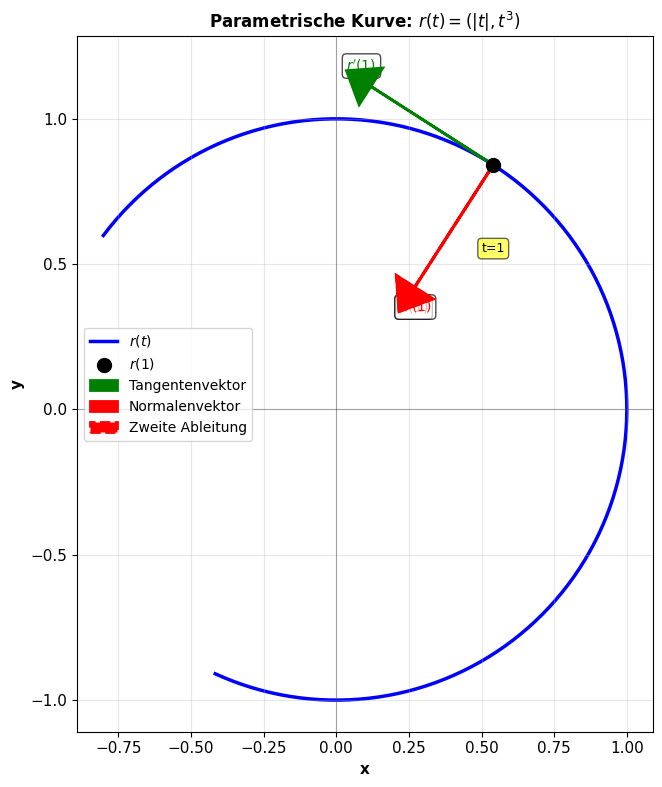

Informationen zu den Evaluationspunkten:

Bei t = 1:
  Position r(1) = (0.5403, 0.8415)
  Tangentenvektor r'(1) ≈ (-0.8415, 0.5403)
  Normalenvektor n(1) ≈ (-0.5403, -0.8415)
  Zweite Ableitung r''(1) ≈ (-0.5403, -0.8415)
  |r'(1)| ≈ 1.0000
  |r''(1)| ≈ 1.0000

Demo 2: Interaktive Kurve r(t) = (|t|, t³) mit Schieberegler
Verwenden Sie den Schieberegler, um verschiedene t-Werte zu erkunden!
------------------------------------------------------------


interactive(children=(FloatSlider(value=-2.0, description='eval_points:', layout=Layout(width='500px'), max=2.…

In [ ]:
# --- Demo: Parametrische 2D-Kurve mit Tangenten- und Normalenvektoren ---

# Beispiel 1: r(t) = (|t|, t³) - Statischer Plot
def r_demo(t):
    """Parametrische Kurve r(t) = (|t|, t³)"""
    return (np.cos(t), np.sin(t))

print("Demo 1: Kurve r(t) = (|t|, t³) mit Tangenten- und Normalenvektor bei t=2")
print("-" * 60)

plot_parametric_curve_2d(
    r_func=r_demo,
    t_range=(-2, 2.5),
    eval_points=[1],
    show_tangent=True,
    show_normal=True,
    vector_scale=0.5,
    title='Parametrische Kurve: $r(t) = (|t|, t^3)$',
    x_label='x',
    y_label='y'
)

print("\n" + "=" * 60)
print("Demo 2: Interaktive Kurve r(t) = (|t|, t³) mit Schieberegler")
print("Verwenden Sie den Schieberegler, um verschiedene t-Werte zu erkunden!")
print("-" * 60)

# Mache den Plot interaktiv mit einem Slider für verschiedene t-Werte
make_interactive_slider(
    plot_parametric_curve_2d,
    param_name='eval_points',
    param_values=[-2, -1.5, -1, -0.5, 0, 0.5, 1, 1.5, 2, 2.5],
    # Alle anderen Parameter bleiben fest:
    r_func=r_demo,
    t_range=(-2, 2.5),
    show_tangent=True,
    show_normal=True,
    vector_scale=0.5,
    title='Parametrische Kurve: $r(t) = (|t|, t^3)$',
    x_label='x',
    y_label='y'
)

Demo: 3D Parametrische Kurven

Beispiel 1: Helix r(t) = (cos(t), sin(t), t/5)
------------------------------------------------------------


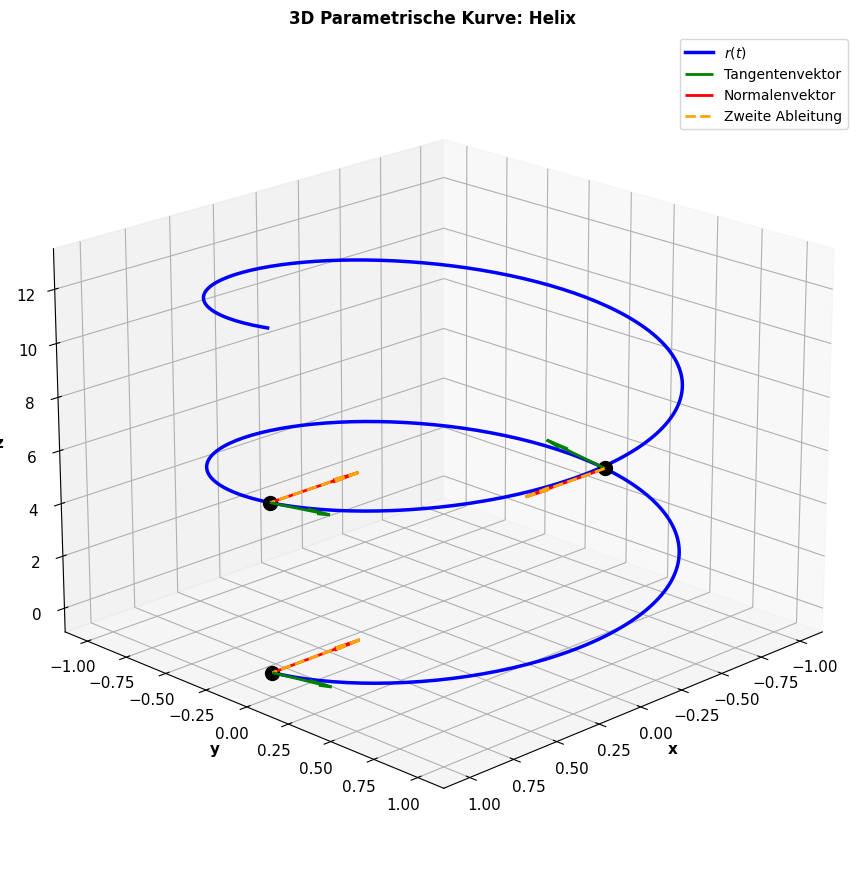

Informationen zu den Evaluationspunkten (3D):

Bei t = 0:
  Position r(0) = (1.0000, 0.0000, 0.0000)
  Tangentenvektor r'(0) ≈ (0.0000, 1.0000, 1.0000)
  Normalenvektor n(0) ≈ (-1.0000, 0.0000, 0.0000)
  Zweite Ableitung r''(0) ≈ (-1.0000, 0.0000, 0.0000)
  |r'(0)| ≈ 1.4142
  |n(0)| ≈ 1.0000
  |r''(0)| ≈ 1.0000

Bei t = 3.141592653589793:
  Position r(3.141592653589793) = (-1.0000, 0.0000, 3.1416)
  Tangentenvektor r'(3.141592653589793) ≈ (0.0000, -1.0000, 1.0000)
  Normalenvektor n(3.141592653589793) ≈ (1.0000, 0.0000, 0.0000)
  Zweite Ableitung r''(3.141592653589793) ≈ (1.0000, 0.0000, 0.0000)
  |r'(3.141592653589793)| ≈ 1.4142
  |n(3.141592653589793)| ≈ 1.0000
  |r''(3.141592653589793)| ≈ 1.0000

Bei t = 6.283185307179586:
  Position r(6.283185307179586) = (1.0000, -0.0000, 6.2832)
  Tangentenvektor r'(6.283185307179586) ≈ (0.0000, 1.0000, 1.0000)
  Normalenvektor n(6.283185307179586) ≈ (-1.0000, 0.0000, -0.0000)
  Zweite Ableitung r''(6.283185307179586) ≈ (-1.0000, 0.0000, 0.0000)


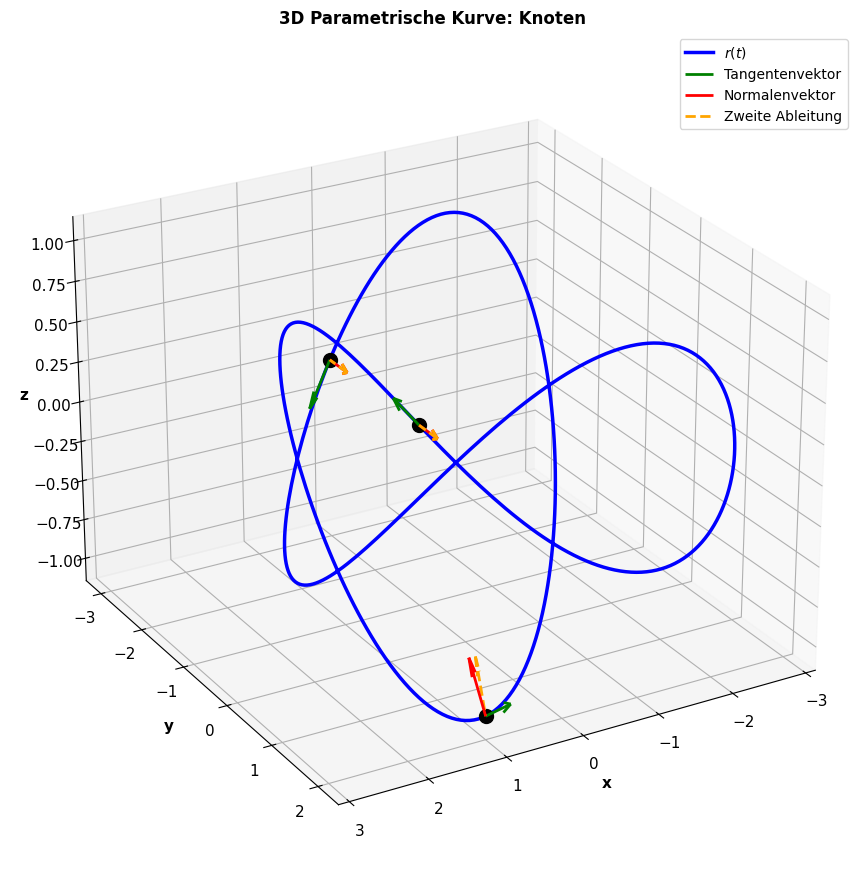

Informationen zu den Evaluationspunkten (3D):

Bei t = 0:
  Position r(0) = (0.0000, -1.0000, 0.0000)
  Tangentenvektor r'(0) ≈ (5.0000, 0.0000, 3.0000)
  Normalenvektor n(0) ≈ (0.0000, 7.0000, 0.0000)
  Zweite Ableitung r''(0) ≈ (0.0000, 7.0000, 0.0000)
  |r'(0)| ≈ 5.8309
  |n(0)| ≈ 7.0000
  |r''(0)| ≈ 7.0000

Bei t = 1.5707963267948966:
  Position r(1.5707963267948966) = (1.0000, 2.0000, -1.0000)
  Tangentenvektor r'(1.5707963267948966) ≈ (-4.0000, -1.0000, 0.0000)
  Normalenvektor n(1.5707963267948966) ≈ (1.8235, -7.2941, 9.0000)
  Zweite Ableitung r''(1.5707963267948966) ≈ (-1.0000, -8.0000, 9.0000)
  |r'(1.5707963267948966)| ≈ 4.1231
  |n(1.5707963267948966)| ≈ 11.7273
  |r''(1.5707963267948966)| ≈ 12.0830

Bei t = 3.141592653589793:
  Position r(3.141592653589793) = (-0.0000, -3.0000, 0.0000)
  Tangentenvektor r'(3.141592653589793) ≈ (3.0000, 0.0000, -3.0000)
  Normalenvektor n(3.141592653589793) ≈ (-0.0000, 9.0000, -0.0000)
  Zweite Ableitung r''(3.141592653589793) ≈ (-0.0000, 9

In [10]:

# --- Demo: 3D Parametrische Kurven ---

print("=" * 60)
print("Demo: 3D Parametrische Kurven")
print("=" * 60)

# Beispiel 1: Helix (Schraubenlinie)
def helix(t):
    """Parametrische Helix: r(t) = (cos(t), sin(t), t/5)"""
    return (np.cos(t), np.sin(t), t )

print("\nBeispiel 1: Helix r(t) = (cos(t), sin(t), t/5)")
print("-" * 60)

plot_parametric_curve_3d(
    r_func=helix,
    t_range=(0, 4 * np.pi),
    eval_points=[0, np.pi, 2*np.pi],
    show_tangent=True,
    show_normal=True,
    show_second_derivative=True,
    vector_scale=0.5,
    title='3D Parametrische Kurve: Helix',
    x_label='x',
    y_label='y',
    z_label='z',
    elev=20,
    azim=45
)

# Beispiel 2: Raumkurve (Knoten)
def knot_curve(t):
    """Eine 3D Raumkurve"""
    return (
        np.sin(t) + 2 * np.sin(2*t),
        np.cos(t) - 2 * np.cos(2*t),
        np.sin(3*t)
    )

print("\nBeispiel 2: 3D Knoten-Kurve r(t) = (sin(t) + 2sin(2t), cos(t) - 2cos(2t), sin(3t))")
print("-" * 60)

plot_parametric_curve_3d(
    r_func=knot_curve,
    t_range=(0, 2*np.pi),
    eval_points=[0, np.pi/2, np.pi],
    show_tangent=True,
    show_normal=True,
    show_second_derivative=True,
    vector_scale=0.4,
    title='3D Parametrische Kurve: Knoten',
    x_label='x',
    y_label='y',
    z_label='z',
    elev=25,
    azim=60
)


In [11]:

# --- Demo: 3D Parametrische Kurven - INTERAKTIV mit Plotly ---

print("=" * 70)
print("INTERAKTIVE 3D Parametrische Kurven (mit Plotly)")
print("=" * 70)
print("\nBedienung:")
print("  • Linksklick + Mausbewegung: Drehen")
print("  • Rechtklick + Mausbewegung: Verschieben")
print("  • Scroll-Rad oder 2-Finger Bewegung: Zoomen")
print("  • Doppelklick: Zurücksetzen")
print("=" * 70 + "\n")

# Beispiel 1: Helix
print("\nBeispiel 1: Interaktive Helix r(t) = (cos(t), sin(t), t/5)")
print("-" * 70)

plot_parametric_curve_3d_interactive(
    r_func=helix,
    t_range=(0, 4 * np.pi),
    eval_points=[0, np.pi, 2*np.pi, 3*np.pi],
    show_tangent=True,
    show_normal=True,
    show_second_derivative=False,
    vector_scale=0.5,
    title='Interaktive 3D Kurve: Helix',
    x_label='x',
    y_label='y',
    z_label='z'
)

# Beispiel 2: Knoten-Kurve
print("\n\nBeispiel 2: Interaktive Knoten-Kurve")
print("-" * 70)

plot_parametric_curve_3d_interactive(
    r_func=knot_curve,
    t_range=(0, 2*np.pi),
    eval_points=[0, np.pi/2, np.pi, 3*np.pi/2],
    show_tangent=True,
    show_normal=True,
    show_second_derivative=False,
    vector_scale=0.4,
    title='Interaktive 3D Kurve: Knoten',
    x_label='x',
    y_label='y',
    z_label='z'
)


INTERAKTIVE 3D Parametrische Kurven (mit Plotly)

Bedienung:
  • Linksklick + Mausbewegung: Drehen
  • Rechtklick + Mausbewegung: Verschieben
  • Scroll-Rad oder 2-Finger Bewegung: Zoomen
  • Doppelklick: Zurücksetzen


Beispiel 1: Interaktive Helix r(t) = (cos(t), sin(t), t/5)
----------------------------------------------------------------------


Informationen zu den Evaluationspunkten (3D Interaktiv):

Bei t = 0.0000:
  Position r(0) = (1.0000, 0.0000, 0.0000)
  Tangentenvektor r'(0) ≈ (0.0000, 1.0000, 1.0000)
  Normalenvektor n(0) ≈ (-1.0000, 0.0000, 0.0000)
  Zweite Ableitung r''(0) ≈ (-1.0000, 0.0000, 0.0000)
  |r'(0)| ≈ 1.4142
  |n(0)| ≈ 1.0000
  |r''(0)| ≈ 1.0000

Bei t = 3.1416:
  Position r(3.141592653589793) = (-1.0000, 0.0000, 3.1416)
  Tangentenvektor r'(3.141592653589793) ≈ (0.0000, -1.0000, 1.0000)
  Normalenvektor n(3.141592653589793) ≈ (1.0000, 0.0000, 0.0000)
  Zweite Ableitung r''(3.141592653589793) ≈ (1.0000, 0.0000, 0.0000)
  |r'(3.141592653589793)| ≈ 1.4142
  |n(3.141592653589793)| ≈ 1.0000
  |r''(3.141592653589793)| ≈ 1.0000

Bei t = 6.2832:
  Position r(6.283185307179586) = (1.0000, -0.0000, 6.2832)
  Tangentenvektor r'(6.283185307179586) ≈ (0.0000, 1.0000, 1.0000)
  Normalenvektor n(6.283185307179586) ≈ (-1.0000, 0.0000, -0.0000)
  Zweite Ableitung r''(6.283185307179586) ≈ (-1.0000, 0.0000, 0.0000)
  |r'(

Informationen zu den Evaluationspunkten (3D Interaktiv):

Bei t = 0.0000:
  Position r(0) = (0.0000, -1.0000, 0.0000)
  Tangentenvektor r'(0) ≈ (5.0000, 0.0000, 3.0000)
  Normalenvektor n(0) ≈ (0.0000, 7.0000, 0.0000)
  Zweite Ableitung r''(0) ≈ (0.0000, 7.0000, 0.0000)
  |r'(0)| ≈ 5.8309
  |n(0)| ≈ 7.0000
  |r''(0)| ≈ 7.0000

Bei t = 1.5708:
  Position r(1.5707963267948966) = (1.0000, 2.0000, -1.0000)
  Tangentenvektor r'(1.5707963267948966) ≈ (-4.0000, -1.0000, 0.0000)
  Normalenvektor n(1.5707963267948966) ≈ (1.8235, -7.2941, 9.0000)
  Zweite Ableitung r''(1.5707963267948966) ≈ (-1.0000, -8.0000, 9.0000)
  |r'(1.5707963267948966)| ≈ 4.1231
  |n(1.5707963267948966)| ≈ 11.7273
  |r''(1.5707963267948966)| ≈ 12.0830

Bei t = 3.1416:
  Position r(3.141592653589793) = (-0.0000, -3.0000, 0.0000)
  Tangentenvektor r'(3.141592653589793) ≈ (3.0000, 0.0000, -3.0000)
  Normalenvektor n(3.141592653589793) ≈ (-0.0000, 9.0000, -0.0000)
  Zweite Ableitung r''(3.141592653589793) ≈ (-0.0000, 9.0000, 

Kritischer Punkt: x ≈ -0.7937, y ≈ -1.8899 (Max)
Wendepunkt/Sattelpunkt: x = 1, y = 0


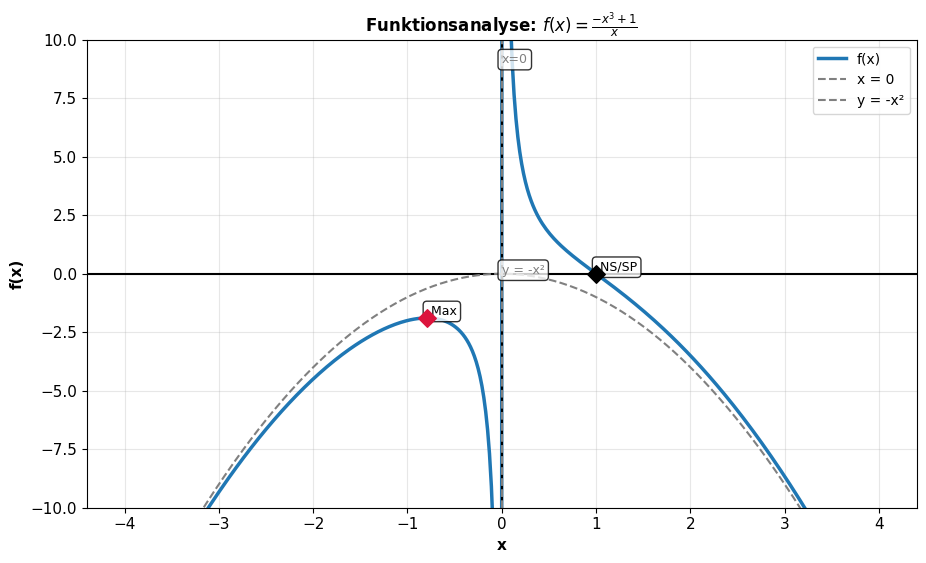


Demo 2: Interaktive Konvergenz mit Schieberegler
------------------------------------------------------------


interactive(children=(IntSlider(value=50, description='n_max:', layout=Layout(width='500px'), max=200, min=1, …

<function __main__.<lambda>(n_max)>

In [ ]:
# --- Demo: Automatisierte Plot-Utilities ---

# 1) Funktionsanalyse mit markierten Punkten und Asymptoten
# Funktion: f(x) = (-x³ + 1) / x = -x² + 1/x

def f_demo(x):
    return (-x**3 + 1) / x

def f_demo_derivative(x):
    """f'(x) = -2x - 1/x²"""
    return -2*x - 1/(x**2)

def f_demo_second_derivative(x):
    """f''(x) = -2 + 2/x³"""
    return -2 + 2/(x**3)

# Berechne kritische Punkte
# f'(x) = 0 => -2x - 1/x² = 0 => -2x³ - 1 = 0 => x³ = -1/2 => x ≈ -0.7937
x_critical = -(0.5)**(1/3)
y_critical = f_demo(x_critical)
f_double_prime = f_demo_second_derivative(x_critical)

# Bestimme ob Max oder Min
if f_double_prime < 0:
    critical_type = "Max"
    maxima_points = [(x_critical, y_critical)]
    minima_points = []
else:
    critical_type = "Min"
    minima_points = [(x_critical, y_critical)]
    maxima_points = []

# Wendepunkte: f''(x) = 0 => -2 + 2/x³ = 0 => x³ = 1 => x = 1
# Aber x=1 ist auch Nullstelle, also Sattelpunkt
wendepunkte_points = [(1, 0)]

print(f"Kritischer Punkt: x ≈ {x_critical:.4f}, y ≈ {y_critical:.4f} ({critical_type})")
print(f"Wendepunkt/Sattelpunkt: x = 1, y = 0")

x_demo = np.linspace(-4, 4, 400)
y_demo = f_demo(x_demo)

plot_function_analysis(
    x_range=(-10, 10),
    x_values=x_demo,
    y_values=y_demo,
    maxima=maxima_points,
    minima=minima_points,
    nullstellen=[(1, 0)],
    sattelpunkte=wendepunkte_points,
    wendepunkte=[],
    asymptoten={
        'vertical': [0],
        'horizontal': [],
        'oblique': [],
        'curved': [(lambda x: -x**2, 'y = -x²')]
    },
    title="Funktionsanalyse: $f(x) = \\frac{-x^3 + 1}{x}$",
    x_label='x',
    y_label='f(x)',
    y_limits=(-10, 10)
)

# 2) Konvergenz-Widget mit interact und plot_convergence
print("\n" + "=" * 60)
print("Demo 2: Interaktive Konvergenz mit Schieberegler")
print("-" * 60)

n_vals_demo = np.arange(1, 201, 2)  # nur ungerade n
a_vals_demo = n_vals_demo / (n_vals_demo + 1)
distance_vals_demo = np.abs(a_vals_demo - 1)

slider_demo = IntSlider(
    value=50,
    min=1,
    max=200,
    step=2,
    description='n_max:',
    style={'description_width': '80px'},
    layout={'width': '500px'}
)

interact(
    lambda n_max: plot_convergence(
        n_values=n_vals_demo,
        a_n=a_vals_demo,
        limit=1,
        n_max=n_max,
        distance=distance_vals_demo,
        epsilon=0.01,
        title='Konvergenz der Folge $a_n = \\frac{n}{n+1}$ gegen Grenzwert 1'
    ),
    n_max=slider_demo
)

In [ ]:
print("=" * 80)
print("📚 WIEDERHOLUNG 1: Lineare Funktion (Aus Übung 1, Aufgabe 1.1.a)")
print("=" * 80)

problem_1_1 = r"""
#### Aufgabe 1.1.a) – Wiederholung: Lineare Funktion

**Analysieren Sie folgende Funktion:**

$$p_1(x) = 2x - 1$$

**Bestimmen Sie:**
- Definitionsbereich $D$
- Nullstellen
- y-Achsenabschnitt
- Monotonie
- Symmetrie

*Versuchen Sie zunächst, diese Aufgabe selbstständig zu lösen!*
"""

solution_1_1 = r"""
#### ✓ Lösungsvorschlag

**Definitionsbereich:** $D = \mathbb{R}$ (linear, für alle reellen Zahlen definiert)

**Nullstellen:**  
Setzen Sie $p_1(x) = 0$:  
$$2x - 1 = 0 \Rightarrow x = \frac{1}{2}$$
Nullstelle: $\left(\frac{1}{2}, 0\right)$

**y-Achsenabschnitt:**  
$p_1(0) = 2(0) - 1 = -1$  
Punkt: $(0, -1)$

**Monotonie:**  
$p_1'(x) = 2 > 0$ für alle $x \in \mathbb{R}$  
→ **Streng monoton steigend**

**Symmetrie:**  
$p_1(-x) = 2(-x) - 1 = -2x - 1 \neq p_1(x)$ und $\neq -p_1(x)$  
→ **Keine Symmetrie**

**Graph:** Eine steigende Gerade mit y-Achsenabschnitt bei $-1$ und Nullstelle bei $x = \frac{1}{2}$
"""

def plot_wiederholung_1():
    plot_function_analysis(
        x_range=(-2, 3),
        func=lambda x: 2 * x - 1,
        maxima=[],
        minima=[],
        nullstellen=[(0.5, 0)],
        sattelpunkte=[],
        wendepunkte=[],
        asymptoten={},
        title="Wiederholung 1: Lineare Funktion"
    )

display(create_solution_toggle(problem_1_1, solution_1_1, "Lösung anzeigen", plot_wiederholung_1))

📚 WIEDERHOLUNG 1: Lineare Funktion (Aus Übung 1, Aufgabe 1.1.a)


In [ ]:
print("\n" + "=" * 80)
print("📚 WIEDERHOLUNG 2: Quadratische Funktion (Aus Übung 1, Aufgabe 1.1.b)")
print("=" * 80 + "\n")

problem_1_2 = r"""
#### Aufgabe 1.1.b) – Wiederholung: Quadratische Funktion

**Analysieren Sie folgende Funktion:**

$$p_2(x) = (x - 2)^2 - 1$$

**Bestimmen Sie:**
- Definitionsbereich $D$
- Nullstellen (Hinweis: Faktorisieren Sie $(x-2)^2 - 1$)
- Scheitelpunkt (Extremstelle)
- Monotonie-Intervalle
- Ist die Funktion gerade oder ungerade?

*Hinweis: Nutzen Sie die Scheitelpunktsform zur Analyse!*
"""

solution_1_2 = r"""
#### ✓ Lösungsvorschlag

**Definitionsbereich:** $D = \mathbb{R}$

**Nullstellen:**  
$(x - 2)^2 - 1 = 0 \Rightarrow (x-2)^2 = 1$  
$x - 2 = \pm 1$  
$x = 2 \pm 1$  
→ Nullstellen: $x_1 = 1$ und $x_2 = 3$  
Punkte: $(1, 0)$ und $(3, 0)$

**Scheitelpunkt:**  
Aus der Scheitelpunktsform $p_2(x) = (x-2)^2 - 1$ liest man ab:  
Scheitelpunkt: $S = (2, -1)$ (Minimum, da Parabel nach oben geöffnet)

**Monotonie:**  
$p_2'(x) = 2(x-2)$
- $p_2'(x) < 0$ für $x < 2$ → **Monoton fallend auf $(-\infty, 2)$**
- $p_2'(x) > 0$ für $x > 2$ → **Monoton steigend auf $(2, \infty)$**

**Symmetrie:** Die Parabel ist achsensymmetrisch zur Geraden $x = 2$.
"""

def plot_wiederholung_2():
    plot_function_analysis(
        x_range=(-0.5, 4.5),
        func=lambda x: (x - 2) ** 2 - 1,
        maxima=[],
        minima=[(2, -1)],
        nullstellen=[(1, 0), (3, 0)],
        sattelpunkte=[],
        wendepunkte=[],
        asymptoten={},
        title="Wiederholung 2: Quadratische Funktion"
    )

# Pass the callback function to create_solution_toggle
display(create_solution_toggle(problem_1_2, solution_1_2, "Lösung anzeigen", plot_wiederholung_2))


📚 WIEDERHOLUNG 2: Quadratische Funktion (Aus Übung 1, Aufgabe 1.1.b)



In [ ]:
print("\n" + "=" * 80)
print("📚 WIEDERHOLUNG 3: Grenzwertkonvergenz und Folgen (Aus Übung 2, Aufgabe 2.3)")
print("=" * 80 + "\n")

problem_1_3 = r"""
#### Aufgabe 2.3) – Wiederholung: Grenzwertkonvergenz von Folgen

**Analysieren Sie folgende Folge:**

$$a_n = \frac{n}{n+1}$$

**Bestimmen Sie:**
- Den Grenzwert $\lim_{n \to \infty} a_n$
- Untersuchen Sie die Konvergenz
- Berechnen Sie die Distanz $|a_n - L|$ für verschiedene $n$ (wobei $L$ der Grenzwert ist)
- Geben Sie an, ab welchem Index $n$ die Abweichung vom Grenzwert kleiner als $\epsilon = 0.01$ ist

*Verwenden Sie den interaktiven Schieberegler zur Erkundung der Konvergenz!*
"""

solution_1_3 = r"""
#### ✓ Lösungsvorschlag

**Grenzwert:**  
$$\lim_{n \to \infty} a_n = \lim_{n \to \infty} \frac{n}{n+1} = \lim_{n \to \infty} \frac{1}{1 + \frac{1}{n}} = 1$$

**Konvergenz:**  
Die Folge konvergiert gegen den Grenzwert $L = 1$. Das bedeutet, für alle noch so kleine Abweichungen $\epsilon > 0$ gibt es ein $N$, sodass $|a_n - 1| < \epsilon$ für alle $n > N$.

**Distanz zum Grenzwert:**  
$$|a_n - 1| = \left|\frac{n}{n+1} - 1\right| = \left|\frac{n - (n+1)}{n+1}\right| = \frac{1}{n+1}$$

Dies zeigt, dass die Distanz mit wachsendem $n$ monoton gegen 0 fällt.

**Konvergenzgeschwindigkeit:**  
Für $\epsilon = 0.01$:  
$$\frac{1}{n+1} < 0.01 \Rightarrow n + 1 > 100 \Rightarrow n > 99$$

Also ist die Abweichung ab $n = 100$ garantiert kleiner als $0.01$.

**Besonderheit:** Diese Folge konvergiert monoton von unten gegen den Grenzwert (alle Glieder sind kleiner als 1).
"""

# Define interactive plot callback
def plot_convergence_interactive():
    """Generate interactive visualization for convergence"""
    # Definiere die Folge
    n_vals_repeat = np.arange(1, 201, 1)
    a_vals_repeat = n_vals_repeat / (n_vals_repeat + 1)
    distance_vals_repeat = np.abs(a_vals_repeat - 1)

    print("Demo: Interaktive Konvergenz mit Schieberegler")
    print("Verwenden Sie den Schieberegler, um verschiedene n_max-Werte zu erkunden!")
    print("-" * 60)

    slider_repeat = IntSlider(
        value=50,
        min=10,
        max=200,
        step=10,
        description='n_max:',
        style={'description_width': '80px'},
        layout={'width': '500px'}
    )

    interact(
        lambda n_max: plot_convergence(
            n_values=n_vals_repeat,
            a_n=a_vals_repeat,
            limit=1,
            n_max=n_max,
            distance=distance_vals_repeat,
            epsilon=0.01,
            title='Konvergenz der Folge $a_n = \\frac{n}{n+1}$ gegen Grenzwert 1'
        ),
        n_max=slider_repeat
    )

# Pass the interactive callback
display(create_solution_toggle(problem_1_3, solution_1_3, "Lösung anzeigen", plot_convergence_interactive))


📚 WIEDERHOLUNG 3: Grenzwertkonvergenz und Folgen (Aus Übung 2, Aufgabe 2.3)



<a id="theorie"></a>
## 📖 Theoretischer Hintergrund

### Konzepte und Definitionen

[Theoretischer Hintergrund zum Thema eintragen]

---

[Weitere theoretische Inhalte eintragen]

<a id="aufgabeblatt"></a>
## 📝 Aufgabeblatt [Nr] – Mathematik II/B Übung [Nr]

Dieses Aufgabeblatt behandelt [Thema eintragen].

---

In [ ]:
# code

<a id="aufgabe1"></a>
## 📝 Aufgabe [Nr].1

**Titel:** [Aufgabentitel eintragen]

[Aufgabenstellung eintragen]

---

[Detaillierte Erklärung und Lösung eintragen]

In [ ]:
# Code für Aufgabe [Nr].1
print("Aufgabe [Nr].1 - Code eintragen")

Aufgabe [Nr].1 - Code eintragen


<a id="aufgabe2"></a>
## 📝 Aufgabe [Nr].2

**Titel:** [Aufgabentitel eintragen]

[Aufgabenstellung eintragen]

---

[Detaillierte Erklärung und Lösung eintragen]

In [ ]:
# Code für Aufgabe [Nr].2
print("Aufgabe [Nr].2 - Code eintragen")

Aufgabe [Nr].2 - Code eintragen


<a id="aufgabe3"></a>
## 📝 Aufgabe [Nr].3

**Titel:** [Aufgabentitel eintragen]

[Aufgabenstellung eintragen]

---

[Detaillierte Erklärung und Lösung eintragen]

In [ ]:
# Code für Aufgabe [Nr].3
print("Aufgabe [Nr].3 - Code eintragen")

Aufgabe [Nr].3 - Code eintragen


<a id="tipps"></a>
## 💡 Lösungstipps

### Tipps zu Aufgabe [Nr].1
[Lösungstipps für Aufgabe [Nr].1 eintragen]

### Tipps zu Aufgabe [Nr].2
[Lösungstipps für Aufgabe [Nr].2 eintragen]

### Tipps zu Aufgabe [Nr].3
[Lösungstipps für Aufgabe [Nr].3 eintragen]

---

## 📚 Weitere Ressourcen

- [Vorheriges Aufgabeblatt](./Mathematik_II_Uebung_01.ipynb)
- [Nächstes Aufgabeblatt](./Mathematik_II_Uebung_02.ipynb)

**Viel Erfolg beim Bearbeiten der Aufgaben!** 🎓